In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# The data

df = pd.read_csv('p3-data.csv')
print(df.shape)
df.head()

(872, 3)


,group,year,employed
0,Geneva,2023,1
1,Lausanne,2024,0
2,Geneva,2024,0
3,Geneva,2024,0
4,Zurich,2024,0


In [ ]:
# Grouping by year and city, average

df.groupby(['group','year']).mean().round(3)

employed
group    year          
Geneva   2023     0.500
         2024     0.550
         2025     0.604
Lausanne 2023     0.506
         2024     0.559
         2025     0.713
Zurich   2023     0.600
         2024     0.570
         2025     0.641

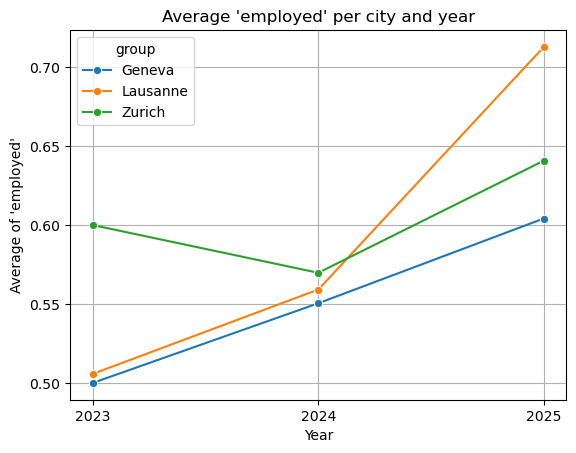

In [ ]:

# Grouped data
df_grouped = df.groupby(['group', 'year']).mean().reset_index()

# Graph
sns.lineplot(
    data=df_grouped,
    x='year',
    y='employed',
    hue='group', 
    marker='o' 
)

plt.title("Average 'employed' per city and year")
plt.xlabel("Year")
plt.xticks([2023,2024,2025])
plt.ylabel("Average of 'employed'")
plt.grid(True)
plt.show()

In [ ]:
# Computing the DiD estimation of ATT

def compute_did_att(df, control_group):

    # Compute group-year means
    means = df.groupby(['group', 'year'])['employed'].mean()

    # Treated group: Lausanne
    treated_before = means.loc[('Lausanne', 2024)]
    treated_after  = means.loc[('Lausanne', 2025)]

    # Control group
    control_before = means.loc[(control_group, 2024)]
    control_after  = means.loc[(control_group, 2025)]

    # Difference-in-Differences
    att = (treated_after - treated_before) - (control_after - control_before)

    return att

att_gen = round(compute_did_att(df,'Geneva'),3)
att_zu = round(compute_did_att(df,'Zurich'),3)
print("ATT estimation w/ Geneva as control group:",att_gen)
print("ATT estimation w/ Zurich as control group:",att_zu)

ATT estimation w/ Geneva as control group 0.1
ATT estimation w/ Zurich as control group 0.083


In [ ]:
# Other (wrong) estimators of the ATT

att_est_1 = 0.713 - 0.559
att_est_2 = 0.713 - 0.604

print("First estimation of ATT:", round(att_est_1,3))
print("Second estimation of ATT:", round(att_est_2,3))

First estimation of ATT: 0.154
Second estimation of ATT: 0.109
